In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ApexPlanet_DataAnalytics_Dataset.xlsx to ApexPlanet_DataAnalytics_Dataset.xlsx


In [ ]:
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [ ]:
df.shape

(1000, 12)

In [ ]:
df.columns


Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Order_ID,992
Order_Date,342
Customer_ID,947
Customer_Name,425
Age,48
Gender,2
City,8
Product,6
Category,5
Quantity,10


In [ ]:
df.dtypes

,0
Order_ID,object
Order_Date,object
Customer_ID,object
Customer_Name,object
Age,float64
Gender,object
City,object
Product,object
Category,object
Quantity,int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.title()

In [ ]:
num_cols

Index(['Age', 'Quantity', 'Unit_Price', 'Total_Sales'], dtype='object')

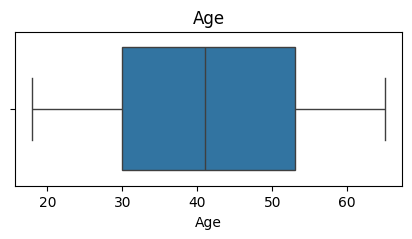

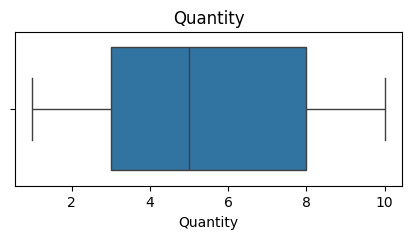

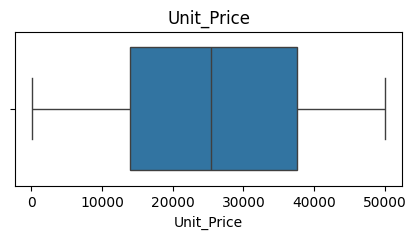

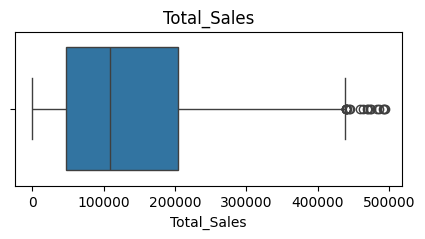

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    df=df[(df[col]>=lower)&(df[col]<=upper)]

In [ ]:
df.to_excel("cleaned_dataset.xlsx",index=False)

In [ ]:
from google.colab import files

files.download("cleaned_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dictionary = pd.DataFrame({
    "Column Name":df.columns,
    "Data Type":df.dtypes.values
})

dictionary.to_excel("Data_Dictionary.xlsx",index=False)

In [ ]:
files.download("Data_Dictionary.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>